In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.join(os.getcwd(), '../../../external/LRP-eXplains-Transformers')
sys.path.append(module_path)

In [3]:
from lxt.efficient import monkey_patch

In [4]:
import torch

In [5]:
from transformers import AutoTokenizer
from transformers.models.bert import modeling_bert

In [6]:
from datasets import load_dataset

dataset = load_dataset("squad_v2")

In [7]:
monkey_patch(modeling_bert)

In [9]:
model_name = "google-bert/bert-large-uncased-whole-word-masking-finetuned-squad"
model = modeling_bert.BertForQuestionAnswering.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [11]:
model.to(device)

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,)

In [13]:
# QA version

from tqdm import tqdm
import json
import pickle

def run_bert_attnlrp_squad_benchmark(model, tokenizer, dataset, run_name, question_first=True, model_topk=2):
    results = []
    top1_label_hits = 0
    top1_model_hits = 0
    total_examples = 0
    total_strict_intersect = 0
    total_span_intersect = 0
    total_strict_union = 0
    total_span_union = 0
    total_strict_iou = 0
    total_span_iou = 0
    model_exact_matches = 0
    lrp_model_exact_matches = 0
    precision_denom = 0
    recall_denom = 0
    total_overlap = 0
    total_overlap_ratio = 0
    total_start_end_skips = 0
    total_empty_answer_skips = 0
    total_unanswerable = 0
    lrp_label_exact_matches = 0
    total_strict_label_intersect = 0
    total_strict_label_union = 0
    total_span_label_intersect = 0
    total_span_label_union = 0
    total_span_label_union = 0
    total_strict_label_iou = 0
    total_span_label_iou = 0
    for example in tqdm(dataset["validation"]):
        question = example["question"]
        context = example["context"]
        answers = example["answers"]["text"]
        answer_start_inds = example["answers"]["answer_start"]
    
        if not answers:
            total_unanswerable += 1
            continue
    
        answer_char_ranges = [ (i, i + len(a)) for (a, i) in zip(answers, answer_start_inds) ]
    
        if question_first:
            tokenized = tokenizer(question, context, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        else:
            tokenized = tokenizer(context, question, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        if input_ids.shape[-1] > 512:
            continue
    
        input_embeds = model.bert.embeddings(input_ids)
        input_embeds.retain_grad()
        output = model(inputs_embeds=input_embeds.requires_grad_())
        # output = model(input_ids.to(device))
    
        # Tokenizer outputs [CLS]<question>[SEP]<context>[SEP]
        # We need to mask the question tokens in the start/end logits, this is standard in QA evals
        sep_token_ind = list(input_ids[0]).index(tokenizer.sep_token_id)
        mask = torch.zeros_like(output.start_logits).bool()
        if question_first:
            mask_slice = [slice(None, None), slice(sep_token_ind + 1, None)]
        else:
            mask_slice = [slice(None, None), slice(None, sep_token_ind + 1)]
        mask[mask_slice] = True
    
        masked_start_logits = output.start_logits.masked_fill(~mask, -float("inf"))
        masked_end_logits = output.end_logits.masked_fill(~mask, -float("inf"))
        start = torch.argmax(masked_start_logits)
        end = torch.argmax(masked_end_logits)
    
        if start > end:
            total_start_end_skips += 1
            continue

        # Get the decoded answer per the model
        model_answer = tokenizer.decode(input_ids[0][start:end + 1], skip_special_tokens=False).replace("<unk>", "x").strip()
        if model_answer == "":
            total_empty_answer_skips += 1
            continue
    
        # Convert from token inds to char inds since that's how the dataset tracks the labels
        char_start = offset_mapping[0][start][0]
        if context[char_start] == " ":
            char_start += 1
        char_end = offset_mapping[0][end][1]

        # Take the answer where the prediction gets the best # chars intersecting over the model and label ranges divided by total # chars in label
        # best_overlap_ratio is the Jaccard similarity
        best_overlap, best_answer_len, best_overlap_ratio = max([ (ans_overlap := (max(0, min(char_end, answer_end) - max(char_start, answer_start))), ans_len := (answer_end - answer_start), ans_overlap / (ans_len + len(model_answer) - ans_overlap)) for (answer_start, answer_end) in answer_char_ranges ], key =lambda x: x[2])
        total_overlap += best_overlap
        total_overlap_ratio += best_overlap_ratio
        precision_denom += len(model_answer)
        recall_denom += best_answer_len
    
        if model_exact_match := (best_overlap_ratio == 1):
            model_exact_matches += 1

        # Now run LRP
        logits = torch.stack((output.start_logits.max(), output.end_logits.max()))
        logits.sum().backward()
        relevance = (input_embeds * input_embeds.grad).sum(-1).masked_fill(~mask, -float("inf"))
        # lrp_input1, lrp_input2 = output.start_logits, output.end_logits
        # lrp_input1[0][0] = 0
        # lrp_input2[0][0] = 0
        # checkpoint_vals, param_vals = lrp.run((lrp_input1, lrp_input2))

        lrp_max = relevance.flatten().argmax()
        lrp_top_token = tokenizer.decode([input_ids[0][lrp_max]], skip_special_tokens=True).strip().replace(chr(9601), "")

        # Do model answer-based accuracy, i.e. is the attribution aligned with the model prediction
        if start <= lrp_max <= end:
            top1_model_hits += 1

        # Do IoU with the model prediction
        # We split into two ways to compute:
        # For Strict IoU we do not count tokens IN BETWEEN start and end because the model is meant to only output 2 signals for start and end.
        # So, strict_intersect = 2, strict_union = 2 if LRP top-2 and the model prediction indices matched exactly
        # strict_intersect = 1, strict_union = 3 if LRP only 1 of the LRP top-2 was a model prediction index
        # strict_intersect = 0, strict_union = 4 if neither LRP top-2 were a model prediction index
        # We double count in the case of single word answers (start = end), and do not consider the second place attributed token if the first
        #   place token was the answer.
        # For Span IoU, we DO count tokens in between start and end
        strict_intersect = 0
        span_intersect = 0
        strict_union = model_topk
        span_union = model_topk
        found_start = False
        found_end = False
        for top_ind in relevance.flatten().topk(model_topk).indices:
            if found_start and found_end:
                break
            if start == top_ind:
                found_start = True
                strict_intersect += 1
                span_intersect += 1

            if end == top_ind:   # Crucial to keep these two as separate ifs for single-word answers
                found_end = True
                strict_intersect += 1
                span_intersect += 1

            if start < top_ind < end:
                strict_union += 1
                span_intersect += 1

            elif top_ind < start or end < top_ind:
                strict_union += 1
                span_union += 1

        if lrp_model_exact_match := (strict_intersect == strict_union):
            lrp_model_exact_matches += 1
        total_strict_intersect += strict_intersect
        total_strict_union += strict_union
        total_span_intersect += span_intersect
        total_span_union += span_union
        total_strict_iou += strict_intersect / strict_union
        total_span_iou += span_intersect / span_union

        # LRP-Label IoU using normalized relevance and positive filtering, like what we assume happens in the AttnLRP paper
        # Also described in AttnLRP paper, we only do this for the model-label exact matches
        strict_label_intersect = None
        span_label_intersect = None
        strict_label_union = None
        span_label_union = None
        lrp_label_exact_match = None
        if model_exact_match:
            pos_inds = torch.where((2 * relevance.flatten() / relevance.flatten().max() - 1).cpu() > 0)[0]
            strict_label_intersect = 0
            span_label_intersect = 0
            strict_label_union = 2
            span_label_union = int(end - start + 1)
            for top_ind in pos_inds:
                if start == top_ind or end == top_ind:
                    span_label_intersect += 1
                    strict_label_intersect += 1
                    if start == top_ind and end == top_ind:
                        strict_label_intersect += 1
    
                if start < top_ind < end:
                    strict_label_union += 1
                    span_label_intersect += 1

                elif top_ind < start or end < top_ind:
                    strict_label_union += 1
                    span_label_union += 1

            if strict_label_intersect / strict_label_union > 1 or span_label_intersect / span_label_union > 1:
                print("ERROR ", strict_label_intersect, strict_label_union, span_label_intersect, span_label_union)
    
            if lrp_label_exact_match := (strict_label_intersect == strict_label_union):
                lrp_label_exact_matches += 1
            total_strict_label_intersect += strict_label_intersect
            total_strict_label_union += strict_label_union
            total_span_label_intersect += span_label_intersect
            total_span_label_union += span_label_union
            total_strict_label_iou += strict_label_intersect / strict_label_union
            total_span_label_iou += span_label_intersect / span_label_union

        # Do label-based accuracy
        if any(lrp_top_token in ans for ans in answers):
            # Is the attribution aligned with the ground truth label
            top1_label_hits += 1

        lrp_top5 = relevance.flatten().topk(k=5)
        lrp_top5_tokens = tokenizer.decode(input_ids[0][lrp_top5.indices.cpu()])
        results.append({
            "example": example,
            "model_exact_match": bool(model_exact_match),
            "lrp_top1_ind": lrp_max.tolist(),
            "model_start_end": (start.detach().cpu().tolist(), end.detach().cpu().tolist()),
            "lrp_top1_token": lrp_top_token,
            "lrp_top5_tokens": lrp_top5_tokens,
            "lrp_top5_relevances": lrp_top5.values.detach().cpu().tolist(),
            "lrp_model_strict_intersect": strict_intersect,
            "lrp_model_strict_union": strict_union,
            "lrp_model_span_intersect": span_intersect,
            "lrp_model_span_union": span_union,
            "lrp_model_exact_match": lrp_model_exact_match,
            "lrp_label_strict_intersect": strict_label_intersect,
            "lrp_label_strict_union": strict_label_union,
            "lrp_label_span_intersect": span_label_intersect,
            "lrp_label_span_union": span_label_union,
            "lrp_label_exact_match": lrp_label_exact_match,
        })

        total_examples += 1
        if not (total_examples % 100):
            precision = float(total_overlap / precision_denom)
            recall = float(total_overlap / recall_denom)
            f1 = float(2 / ((1 / precision) + (1 / recall)))
            print("Total examples: ", total_examples)
            print("Model exact matches: ", model_exact_matches)
            print("Model exact match %: ", model_exact_matches / total_examples)
            print("Model precision: ", precision)
            print("Model recall: ", recall)
            print("Model F1: ", f1)
            print("Model overlap ratio: ", float(total_overlap_ratio / total_examples))
            print("LRP Top-1 model answer hits: ", top1_model_hits)
            print("LRP Top-1 model answer hit %: ", top1_model_hits / total_examples)
            print("LRP Top-1 label answer hits: ", top1_label_hits)
            print("LRP Top-1 label answer hit %: ", top1_label_hits / total_examples)
            print(f"LRP Top-{model_topk} Strict Accuracy: ", total_strict_intersect / (model_topk * total_examples))
            print(f"LRP Top-{model_topk} Span Accuracy: ", total_span_intersect / (model_topk * total_examples))
            print("LRP-Model exact matches: ", lrp_model_exact_matches)
            print("LRP-Model Strict IoU: ", total_strict_intersect / total_strict_union)
            print("LRP-Model Span IoU: ", total_span_intersect / total_span_union)
            print("LRP-Model Avg Strict IoU: ", total_strict_iou / total_examples)
            print("LRP-Model Avg Span IoU: ", total_span_iou / total_examples)
            print("LRP-Label exact matches: ", lrp_label_exact_matches)
            print("LRP-Label Strict IoU: ", total_strict_label_intersect / total_strict_label_union)
            print("LRP-Label Span IoU: ", total_span_label_intersect / total_span_label_union)
            print("LRP-Label Avg Strict IoU: ", total_strict_label_iou / model_exact_matches)
            print("LRP-Label Avg Span IoU: ", total_span_label_iou / model_exact_matches)
            print("Total start-end skips: ", total_start_end_skips)
            print("Total empty model answer skips: ", total_empty_answer_skips)
            print("Total unanswerable: ", total_unanswerable)

    precision = float(total_overlap / precision_denom)
    recall = float(total_overlap / recall_denom)
    f1 = float(2 / ((1 / precision) + (1 / recall)))
    data = {
        "summary": {
            "total_examples": total_examples,
            "model_exact_matches": model_exact_matches,
            "model_exact_match_pct": model_exact_matches / total_examples,
            "model_precision": precision,
            "model_recall": recall,
            "model_f1": f1,
            "model_overlap_ratio": float(total_overlap_ratio / total_examples),
            "lrp_top1_model_answer_hits": top1_model_hits,
            "lrp_top1_model_answer_hit_pct": top1_model_hits / total_examples,
            "lrp_top1_label_answer_hits": top1_label_hits,
            "lrp_top1_label_answer_hit_pct": top1_label_hits / total_examples,
            f"lrp_top{model_topk}_strict_accuracy": total_strict_intersect / (model_topk * total_examples),
            f"lrp_top{model_topk}_span_accuracy": total_span_intersect / (model_topk * total_examples),
            "lrp_model_exact_matches": lrp_model_exact_matches,
            "lrp_model_strict_iou": total_strict_intersect / total_strict_union,
            "lrp_model_span_iou": total_span_intersect / total_span_union,
            "lrp_model_avg_strict_iou": total_strict_iou / total_examples,
            "lrp_model_avg_span_iou": total_span_iou / total_examples,
            "lrp_label_exact_matches": lrp_label_exact_matches,
            "lrp_label_strict_iou": total_strict_label_intersect / total_strict_label_union,
            "lrp_label_span_iou": total_span_label_intersect / total_span_label_union,
            "lrp_label_avg_strict_iou": total_strict_label_iou / model_exact_matches,
            "lrp_label_avg_span_iou": total_span_label_iou / model_exact_matches,
            "total_start_end_skips" : total_start_end_skips,
            "total_empty_answer_skips" : total_empty_answer_skips,
            "total_unanswerable" : total_unanswerable,
        },
        "results": results
    }

    try:
        with open(f"bert_results_{run_name}.json", "w") as f:
            json.dump(data, f, indent=4)
    except TypeError:
        print("Failed JSON write, attempting pickle...")
        try:
            with open(f"bert_attnlrp_squad_results_{run_name}.pkl", "wb") as f:
                pickle.dump(data, f)
        except Exception as e:
            print("Encountered exception while pickling, will return (data, exception)...")
            return data, e
    return data

In [ ]:
{
    "summary": {
        "total_examples": 5830,
        "model_exact_matches": 4254,
        "model_exact_match_pct": 0.7296740994854203,
        "model_precision": 0.8107277750968933,
        "model_recall": 0.9040498733520508,
        "model_f1": 0.8548494238448885,
        "model_overlap_ratio": 0.8892877101898193,
        "lrp_top1_model_answer_hits": 4692,
        "lrp_top1_model_answer_hit_pct": 0.8048027444253859,
        "lrp_top1_label_answer_hits": 3015,
        "lrp_top1_label_answer_hit_pct": 0.5171526586620926,
        "lrp_top2_strict_accuracy": 0.3661234991423671,
        "lrp_top2_span_accuracy": 0.39691252144082334,
        "lrp_model_exact_matches": 619,
        "lrp_model_strict_iou": 0.27947398513435673,
        "lrp_model_span_iou": 0.3021726700971907,
        "lrp_label_exact_matches": 150,
        "lrp_label_strict_iou": 0.23905120761010562,
        "lrp_label_span_iou": 0.16233309908643712,
        "lrp_label_avg_strict_iou": 0.25981932970649435,
        "lrp_label_avg_span_iou": 0.22439626745109859,
        "total_start_end_skips": 52,
        "total_empty_answer_skips": 0,
        "total_unanswerable": 5945
    }
}

In [14]:
results = run_bert_attnlrp_squad_benchmark(model, tokenizer, dataset, "attnlrp_squad2")

  2%|█▌                                                                            | 229/11873 [00:06<04:58, 38.99it/s]

Total examples:  100
Model exact matches:  68
Model exact match %:  0.68
Model precision:  0.3335290551185608
Model recall:  0.8994457721710205
Model F1:  0.4866138251695671
Model overlap ratio:  0.7806342244148254
LRP Top-1 model answer hits:  53
LRP Top-1 model answer hit %:  0.53
LRP Top-1 label answer hits:  38
LRP Top-1 label answer hit %:  0.38
LRP Top-2 Strict Accuracy:  0.47
LRP Top-2 Span Accuracy:  0.535
LRP-Model exact matches:  28
LRP-Model Strict IoU:  0.3051948051948052
LRP-Model Span IoU:  0.36271186440677966
LRP-Model Avg Strict IoU:  0.4066666666666668
LRP-Model Avg Span IoU:  0.4833333333333333
LRP-Label exact matches:  9
LRP-Label Strict IoU:  0.3412322274881517
LRP-Label Span IoU:  0.25287356321839083
LRP-Label Avg Strict IoU:  0.4056372549019609
LRP-Label Avg Span IoU:  0.34353514132925905
Total start-end skips:  3
Total empty model answer skips:  0
Total unanswerable:  117


  4%|███                                                                           | 466/11873 [00:12<05:00, 38.01it/s]

Total examples:  200
Model exact matches:  107
Model exact match %:  0.535
Model precision:  0.3397557735443115
Model recall:  0.8106183409690857
Model F1:  0.47882207711472413
Model overlap ratio:  0.6895554065704346
LRP Top-1 model answer hits:  99
LRP Top-1 model answer hit %:  0.495
LRP Top-1 label answer hits:  95
LRP Top-1 label answer hit %:  0.475
LRP Top-2 Strict Accuracy:  0.415
LRP Top-2 Span Accuracy:  0.4925
LRP-Model exact matches:  48
LRP-Model Strict IoU:  0.260596546310832
LRP-Model Span IoU:  0.3250825082508251
LRP-Model Avg Strict IoU:  0.35666666666666663
LRP-Model Avg Span IoU:  0.44166666666666626
LRP-Label exact matches:  13
LRP-Label Strict IoU:  0.3253731343283582
LRP-Label Span IoU:  0.26262626262626265
LRP-Label Avg Strict IoU:  0.3880062305295951
LRP-Label Avg Span IoU:  0.34822794028401505
Total start-end skips:  16
Total empty model answer skips:  0
Total unanswerable:  245


  6%|████▍                                                                         | 681/11873 [00:18<06:34, 28.37it/s]

...

 97%|█████████████████████████████████████████████████████████████████████████▉  | 11545/11873 [05:09<00:09, 34.90it/s]

Total examples:  5400
Model exact matches:  2960
Model exact match %:  0.5481481481481482
Model precision:  0.43769457936286926
Model recall:  0.7820599675178528
Model F1:  0.5612660504437359
Model overlap ratio:  0.7177598476409912
LRP Top-1 model answer hits:  2863
LRP Top-1 model answer hit %:  0.5301851851851852
LRP Top-1 label answer hits:  2908
LRP Top-1 label answer hit %:  0.5385185185185185
LRP Top-2 Strict Accuracy:  0.43222222222222223
LRP Top-2 Span Accuracy:  0.5183333333333333
LRP-Model exact matches:  1338
LRP-Model Strict IoU:  0.27387937103966203
LRP-Model Span IoU:  0.34739977659178356
LRP-Model Avg Strict IoU:  0.3707407407407323
LRP-Model Avg Span IoU:  0.46364197530864126
LRP-Label exact matches:  575
LRP-Label Strict IoU:  0.31783932930064734
LRP-Label Span IoU:  0.22833770153284091
LRP-Label Avg Strict IoU:  0.4040701415701427
LRP-Label Avg Span IoU:  0.35324298656668135
Total start-end skips:  304
Total empty model answer skips:  0
Total unanswerable:  5787


 99%|███████████████████████████████████████████████████████████████████████████▏| 11743/11873 [05:14<00:03, 37.04it/s]

Total examples:  5500
Model exact matches:  3017
Model exact match %:  0.5485454545454546
Model precision:  0.4293704330921173
Model recall:  0.7819793224334717
Model F1:  0.5543548406408169
Model overlap ratio:  0.7170161008834839
LRP Top-1 model answer hits:  2896
LRP Top-1 model answer hit %:  0.5265454545454545
LRP Top-1 label answer hits:  2971
LRP Top-1 label answer hit %:  0.5401818181818182
LRP Top-2 Strict Accuracy:  0.43
LRP Top-2 Span Accuracy:  0.5152727272727273
LRP-Model exact matches:  1354
LRP-Model Strict IoU:  0.272073626689675
LRP-Model Span IoU:  0.3446221195354776
LRP-Model Avg Strict IoU:  0.3687272727272642
LRP-Model Avg Span IoU:  0.4606060606060606
LRP-Label exact matches:  582
LRP-Label Strict IoU:  0.3163265306122449
LRP-Label Span IoU:  0.22816482915005082
LRP-Label Avg Strict IoU:  0.4017172530265018
LRP-Label Avg Span IoU:  0.35183064294371447
Total start-end skips:  311
Total empty model answer skips:  0
Total unanswerable:  5882


100%|████████████████████████████████████████████████████████████████████████████| 11873/11873 [05:18<00:00, 37.29it/s]


In [10]:
context = """Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50."""
question = "Which NFL team represented the AFC at Super Bowl 50?"
input_ids = tokenizer(question, context, return_tensors="pt")
input_embeds = model.bert.embeddings(input_ids["input_ids"].to(device))

In [11]:
input_embeds.retain_grad()

In [12]:
input_embeds.shape

torch.Size([1, 171, 1024])

In [13]:
output = model(inputs_embeds=input_embeds.requires_grad_())

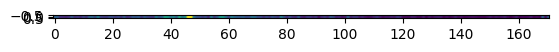

In [15]:
from matplotlib import pyplot as plt

plt.imshow((output.start_logits + output.end_logits).float().cpu().detach().numpy())

In [16]:
output.start_logits.argmax(), output.end_logits.argmax()
tokenizer.decode(input_ids["input_ids"][0, output.start_logits.argmax():output.end_logits.argmax() + 1])

'denver broncos'

In [18]:
import time
start = time.time()
logits = torch.stack((output.start_logits.max(), output.end_logits.max()))
logits.sum().backward()
relevance = (input_embeds * input_embeds.grad).sum(-1)
print(time.time() - start, "seconds")

0.29701924324035645 seconds


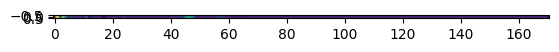

In [20]:
plt.imshow(relevance.detach().float().cpu().numpy())

In [21]:
relevance.topk(5)

torch.return_types.topk(
values=tensor([[11.2500,  8.1250,  6.1875,  4.7188,  3.8594]], device='cuda:0',
       dtype=torch.bfloat16, grad_fn=<TopkBackward0>),
indices=tensor([[ 1,  3, 46, 47, 45]], device='cuda:0'))

# Using DynamicLRP

In [1]:
from transformers import AutoModelForQuestionAnswering, AutoTokenizer
import torch

In [2]:
import os
import sys
module_path = os.path.join(os.getcwd(), '../..')
sys.path.append(module_path)

In [3]:
from lrp_engine import LRPEngine

In [4]:
from datasets import load_dataset

dataset = load_dataset("squad_v2")

In [5]:
model_name = "google-bert/bert-large-uncased-whole-word-masking-finetuned-squad"
model = AutoModelForQuestionAnswering.from_pretrained(model_name, torch_dtype=torch.bfloat16)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Some weights of the model checkpoint at google-bert/bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [7]:
model.to(device)

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,)

In [8]:
lrp = LRPEngine(dtype=torch.bfloat16)

In [9]:
# QA version

from tqdm import tqdm
import json
import pickle

def run_bert_dynamiclrp_squad_benchmark(model, tokenizer, lrp, dataset, run_name, question_first=True, model_topk=2):
    results = []
    top1_label_hits = 0
    top1_model_hits = 0
    total_examples = 0
    total_strict_intersect = 0
    total_span_intersect = 0
    total_strict_union = 0
    total_span_union = 0
    total_strict_iou = 0
    total_span_iou = 0
    model_exact_matches = 0
    lrp_model_exact_matches = 0
    precision_denom = 0
    recall_denom = 0
    total_overlap = 0
    total_overlap_ratio = 0
    total_start_end_skips = 0
    total_empty_answer_skips = 0
    total_unanswerable = 0
    lrp_label_exact_matches = 0
    total_strict_label_intersect = 0
    total_strict_label_union = 0
    total_span_label_intersect = 0
    total_span_label_union = 0
    total_span_label_union = 0
    total_strict_label_iou = 0
    total_span_label_iou = 0
    for example in tqdm(dataset["validation"]):
        question = example["question"]
        context = example["context"]
        answers = example["answers"]["text"]
        answer_start_inds = example["answers"]["answer_start"]
    
        if not answers:
            total_unanswerable += 1
            continue
    
        answer_char_ranges = [ (i, i + len(a)) for (a, i) in zip(answers, answer_start_inds) ]
    
        if question_first:
            tokenized = tokenizer(question, context, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        else:
            tokenized = tokenizer(context, question, return_tensors="pt", return_offsets_mapping=True)
            input_ids = tokenized["input_ids"].to(device)
            offset_mapping = tokenized["offset_mapping"]
        if input_ids.shape[-1] > 512:
            continue
    
        output = model(input_ids.to(device))
    
        # Tokenizer outputs [CLS]<question>[SEP]<context>[SEP]
        # We need to mask the question tokens in the start/end logits, this is standard in QA evals
        sep_token_ind = list(input_ids[0]).index(tokenizer.sep_token_id)
        mask = torch.zeros_like(output.start_logits).bool()
        if question_first:
            mask_slice = [slice(None, None), slice(sep_token_ind + 1, None)]
        else:
            mask_slice = [slice(None, None), slice(None, sep_token_ind + 1)]
        mask[mask_slice] = True
    
        masked_start_logits = output.start_logits.masked_fill(~mask, -float("inf"))
        masked_end_logits = output.end_logits.masked_fill(~mask, -float("inf"))
        start = torch.argmax(masked_start_logits)
        end = torch.argmax(masked_end_logits)
    
        if start > end:
            total_start_end_skips += 1
            continue

        # Get the decoded answer per the model
        model_answer = tokenizer.decode(input_ids[0][start:end + 1], skip_special_tokens=False).replace("<unk>", "x").strip()
        if model_answer == "":
            total_empty_answer_skips += 1
            continue
    
        # Convert from token inds to char inds since that's how the dataset tracks the labels
        char_start = offset_mapping[0][start][0]
        if context[char_start] == " ":
            char_start += 1
        char_end = offset_mapping[0][end][1]

        # Take the answer where the prediction gets the best # chars intersecting over the model and label ranges divided by total # chars in label
        # best_overlap_ratio is the Jaccard similarity
        best_overlap, best_answer_len, best_overlap_ratio = max([ (ans_overlap := (max(0, min(char_end, answer_end) - max(char_start, answer_start))), ans_len := (answer_end - answer_start), ans_overlap / (ans_len + len(model_answer) - ans_overlap)) for (answer_start, answer_end) in answer_char_ranges ], key =lambda x: x[2])
        total_overlap += best_overlap
        total_overlap_ratio += best_overlap_ratio
        precision_denom += len(model_answer)
        recall_denom += best_answer_len
    
        if model_exact_match := (best_overlap_ratio == 1):
            model_exact_matches += 1

        # Now run LRP
        lrp_input1, lrp_input2 = output.start_logits, output.end_logits
        lrp_input1[0][0] = 0
        lrp_input2[0][0] = 0
        checkpoint_vals, param_vals = lrp.run((lrp_input1, lrp_input2))
        relevance = param_vals[0].masked_fill(~mask, -float("inf"))

        lrp_max = relevance.flatten().argmax()
        lrp_top_token = tokenizer.decode([input_ids[0][lrp_max]], skip_special_tokens=True).strip().replace(chr(9601), "")

        # Do model answer-based accuracy, i.e. is the attribution aligned with the model prediction
        if start <= lrp_max <= end:
            top1_model_hits += 1

        # Do IoU with the model prediction
        # We split into two ways to compute:
        # For Strict IoU we do not count tokens IN BETWEEN start and end because the model is meant to only output 2 signals for start and end.
        # So, strict_intersect = 2, strict_union = 2 if LRP top-2 and the model prediction indices matched exactly
        # strict_intersect = 1, strict_union = 3 if LRP only 1 of the LRP top-2 was a model prediction index
        # strict_intersect = 0, strict_union = 4 if neither LRP top-2 were a model prediction index
        # We double count in the case of single word answers (start = end), and do not consider the second place attributed token if the first
        #   place token was the answer.
        # For Span IoU, we DO count tokens in between start and end
        strict_intersect = 0
        span_intersect = 0
        strict_union = model_topk
        span_union = model_topk
        found_start = False
        found_end = False
        for top_ind in relevance.flatten().topk(model_topk).indices:
            if found_start and found_end:
                break
            if start == top_ind:
                found_start = True
                strict_intersect += 1
                span_intersect += 1

            if end == top_ind:   # Crucial to keep these two as separate ifs for single-word answers
                found_end = True
                strict_intersect += 1
                span_intersect += 1

            if start < top_ind < end:
                strict_union += 1
                span_intersect += 1

            elif top_ind < start or end < top_ind:
                strict_union += 1
                span_union += 1

        if lrp_model_exact_match := (strict_intersect == strict_union):
            lrp_model_exact_matches += 1
        total_strict_intersect += strict_intersect
        total_strict_union += strict_union
        total_span_intersect += span_intersect
        total_span_union += span_union
        total_strict_iou += strict_intersect / strict_union
        total_span_iou += span_intersect / span_union

        # LRP-Label IoU using normalized relevance and positive filtering, like what we assume happens in the AttnLRP paper
        # Also described in AttnLRP paper, we only do this for the model-label exact matches
        strict_label_intersect = None
        span_label_intersect = None
        strict_label_union = None
        span_label_union = None
        lrp_label_exact_match = None
        if model_exact_match:
            pos_inds = torch.where((2 * relevance.flatten() / relevance.flatten().max() - 1).cpu() > 0)[0]
            strict_label_intersect = 0
            span_label_intersect = 0
            strict_label_union = 2
            span_label_union = int(end - start + 1)
            for top_ind in pos_inds:
                if start == top_ind or end == top_ind:
                    span_label_intersect += 1
                    strict_label_intersect += 1
                    if start == top_ind and end == top_ind:
                        strict_label_intersect += 1
    
                if start < top_ind < end:
                    strict_label_union += 1
                    span_label_intersect += 1

                elif top_ind < start or end < top_ind:
                    strict_label_union += 1
                    span_label_union += 1

            if strict_label_intersect / strict_label_union > 1 or span_label_intersect / span_label_union > 1:
                print("ERROR ", strict_label_intersect, strict_label_union, span_label_intersect, span_label_union)
    
            if lrp_label_exact_match := (strict_label_intersect == strict_label_union):
                lrp_label_exact_matches += 1
            total_strict_label_intersect += strict_label_intersect
            total_strict_label_union += strict_label_union
            total_span_label_intersect += span_label_intersect
            total_span_label_union += span_label_union
            total_strict_label_iou += strict_label_intersect / strict_label_union
            total_span_label_iou += span_label_intersect / span_label_union

        # Do label-based accuracy
        if any(lrp_top_token in ans for ans in answers):
            # Is the attribution aligned with the ground truth label
            top1_label_hits += 1

        lrp_top5 = relevance.flatten().topk(k=5)
        lrp_top5_tokens = tokenizer.decode(input_ids[0][lrp_top5.indices.cpu()])
        results.append({
            "example": example,
            "model_exact_match": bool(model_exact_match),
            "lrp_top1_ind": lrp_max.tolist(),
            "model_start_end": (start.detach().cpu().tolist(), end.detach().cpu().tolist()),
            "lrp_top1_token": lrp_top_token,
            "lrp_top5_tokens": lrp_top5_tokens,
            "lrp_top5_relevances": lrp_top5.values.detach().cpu().tolist(),
            "lrp_model_strict_intersect": strict_intersect,
            "lrp_model_strict_union": strict_union,
            "lrp_model_span_intersect": span_intersect,
            "lrp_model_span_union": span_union,
            "lrp_model_exact_match": lrp_model_exact_match,
            "lrp_label_strict_intersect": strict_label_intersect,
            "lrp_label_strict_union": strict_label_union,
            "lrp_label_span_intersect": span_label_intersect,
            "lrp_label_span_union": span_label_union,
            "lrp_label_exact_match": lrp_label_exact_match,
        })

        total_examples += 1
        if not (total_examples % 100):
            precision = float(total_overlap / precision_denom)
            recall = float(total_overlap / recall_denom)
            f1 = float(2 / ((1 / precision) + (1 / recall)))
            print("Total examples: ", total_examples)
            print("Model exact matches: ", model_exact_matches)
            print("Model exact match %: ", model_exact_matches / total_examples)
            print("Model precision: ", precision)
            print("Model recall: ", recall)
            print("Model F1: ", f1)
            print("Model overlap ratio: ", float(total_overlap_ratio / total_examples))
            print("LRP Top-1 model answer hits: ", top1_model_hits)
            print("LRP Top-1 model answer hit %: ", top1_model_hits / total_examples)
            print("LRP Top-1 label answer hits: ", top1_label_hits)
            print("LRP Top-1 label answer hit %: ", top1_label_hits / total_examples)
            print(f"LRP Top-{model_topk} Strict Accuracy: ", total_strict_intersect / (model_topk * total_examples))
            print(f"LRP Top-{model_topk} Span Accuracy: ", total_span_intersect / (model_topk * total_examples))
            print("LRP-Model exact matches: ", lrp_model_exact_matches)
            print("LRP-Model Strict IoU: ", total_strict_intersect / total_strict_union)
            print("LRP-Model Span IoU: ", total_span_intersect / total_span_union)
            print("LRP-Model Avg Strict IoU: ", total_strict_iou / total_examples)
            print("LRP-Model Avg Span IoU: ", total_span_iou / total_examples)
            print("LRP-Label exact matches: ", lrp_label_exact_matches)
            print("LRP-Label Strict IoU: ", total_strict_label_intersect / total_strict_label_union)
            print("LRP-Label Span IoU: ", total_span_label_intersect / total_span_label_union)
            print("LRP-Label Avg Strict IoU: ", total_strict_label_iou / model_exact_matches)
            print("LRP-Label Avg Span IoU: ", total_span_label_iou / model_exact_matches)
            print("Total start-end skips: ", total_start_end_skips)
            print("Total empty model answer skips: ", total_empty_answer_skips)
            print("Total unanswerable: ", total_unanswerable)

    precision = float(total_overlap / precision_denom)
    recall = float(total_overlap / recall_denom)
    f1 = float(2 / ((1 / precision) + (1 / recall)))
    data = {
        "summary": {
            "total_examples": total_examples,
            "model_exact_matches": model_exact_matches,
            "model_exact_match_pct": model_exact_matches / total_examples,
            "model_precision": precision,
            "model_recall": recall,
            "model_f1": f1,
            "model_overlap_ratio": float(total_overlap_ratio / total_examples),
            "lrp_top1_model_answer_hits": top1_model_hits,
            "lrp_top1_model_answer_hit_pct": top1_model_hits / total_examples,
            "lrp_top1_label_answer_hits": top1_label_hits,
            "lrp_top1_label_answer_hit_pct": top1_label_hits / total_examples,
            f"lrp_top{model_topk}_strict_accuracy": total_strict_intersect / (model_topk * total_examples),
            f"lrp_top{model_topk}_span_accuracy": total_span_intersect / (model_topk * total_examples),
            "lrp_model_exact_matches": lrp_model_exact_matches,
            "lrp_model_strict_iou": total_strict_intersect / total_strict_union,
            "lrp_model_span_iou": total_span_intersect / total_span_union,
            "lrp_model_strict_iou": total_strict_iou / total_examples,
            "lrp_model_span_iou": total_span_iou / total_examples,
            "lrp_label_exact_matches": lrp_label_exact_matches,
            "lrp_label_strict_iou": total_strict_label_intersect / total_strict_label_union,
            "lrp_label_span_iou": total_span_label_intersect / total_span_label_union,
            "lrp_label_avg_strict_iou": total_strict_label_iou / model_exact_matches,
            "lrp_label_avg_span_iou": total_span_label_iou / model_exact_matches,
            "total_start_end_skips" : total_start_end_skips,
            "total_empty_answer_skips" : total_empty_answer_skips,
            "total_unanswerable" : total_unanswerable,
        },
        "results": results
    }

    try:
        with open(f"bert_dynamiclrp_squad_results_{run_name}.json", "w") as f:
            json.dump(data, f, indent=4)
    except TypeError:
        print("Failed JSON write, attempting pickle...")
        try:
            with open(f"bert_dynamiclrp_squad_results_{run_name}.pkl", "wb") as f:
                pickle.dump(data, f)
        except Exception as e:
            print("Encountered exception while pickling, will return (data, exception)...")
            return data, e
    return data

In [10]:
results = run_bert_dynamiclrp_squad_benchmark(model, tokenizer, lrp, dataset, "bert_dynamiclrp_squad")

  2%|█▍                                                                            | 217/11873 [00:17<12:21, 15.72it/s]

Total examples:  100
Model exact matches:  74
Model exact match %:  0.74
Model precision:  0.8381679654121399
Model recall:  0.9336734414100647
Model F1:  0.8833467439386377
Model overlap ratio:  0.8528570532798767
LRP Top-1 model answer hits:  100
LRP Top-1 model answer hit %:  1.0
LRP Top-1 label answer hits:  37
LRP Top-1 label answer hit %:  0.37
LRP Top-2 Strict Accuracy:  0.905
LRP Top-2 Span Accuracy:  0.96
LRP-Model exact matches:  82
LRP-Model Strict IoU:  0.8264840182648402
LRP-Model Span IoU:  0.9230769230769231
LRP-Model Avg Strict IoU:  0.8766666666666666
LRP-Model Avg Span IoU:  0.9466666666666668
LRP-Label exact matches:  47
LRP-Label Strict IoU:  0.803680981595092
LRP-Label Span IoU:  0.5934579439252337
LRP-Label Avg Strict IoU:  0.8297297297297295
LRP-Label Avg Span IoU:  0.7133204633204633
Total start-end skips:  0
Total empty model answer skips:  0
Total unanswerable:  117


  4%|██▊                                                                           | 427/11873 [00:35<14:10, 13.46it/s]

Total examples:  200
Model exact matches:  144
Model exact match %:  0.72
Model precision:  0.8032393455505371
Model recall:  0.8968519568443298
Model F1:  0.8474683422667608
Model overlap ratio:  0.8474608063697815
LRP Top-1 model answer hits:  196
LRP Top-1 model answer hit %:  0.98
LRP Top-1 label answer hits:  119
LRP Top-1 label answer hit %:  0.595
LRP Top-2 Strict Accuracy:  0.88
LRP Top-2 Span Accuracy:  0.9475
LRP-Model exact matches:  156
LRP-Model Strict IoU:  0.7857142857142857
LRP-Model Span IoU:  0.9002375296912114
LRP-Model Avg Strict IoU:  0.8466666666666669
LRP-Model Avg Span IoU:  0.9350000000000003
LRP-Label exact matches:  91
LRP-Label Strict IoU:  0.779874213836478
LRP-Label Span IoU:  0.5714285714285714
LRP-Label Avg Strict IoU:  0.8146990740740739
LRP-Label Avg Span IoU:  0.7000440917107588
Total start-end skips:  0
Total empty model answer skips:  0
Total unanswerable:  227


  5%|████▏                                                                         | 643/11873 [00:53<15:51, 11.80it/s]

...

 98%|██████████████████████████████████████████████████████████████████████████▍ | 11628/11873 [16:45<00:24, 10.05it/s]

Total examples:  5700
Model exact matches:  4160
Model exact match %:  0.7298245614035088
Model precision:  0.8260533809661865
Model recall:  0.9054067134857178
Model F1:  0.8639116537780949
Model overlap ratio:  0.891055703163147
LRP Top-1 model answer hits:  5626
LRP Top-1 model answer hit %:  0.9870175438596491
LRP Top-1 label answer hits:  3280
LRP Top-1 label answer hit %:  0.5754385964912281
LRP Top-2 Strict Accuracy:  0.873859649122807
LRP Top-2 Span Accuracy:  0.9633333333333334
LRP-Model exact matches:  4314
LRP-Model Strict IoU:  0.7754943172972132
LRP-Model Span IoU:  0.9286318281752072
LRP-Model Avg Strict IoU:  0.8348538011695926
LRP-Model Avg Span IoU:  0.9519883040935653
LRP-Label exact matches:  2347
LRP-Label Strict IoU:  0.7416481069042317
LRP-Label Span IoU:  0.47438075017692855
LRP-Label Avg Strict IoU:  0.7802449633699625
LRP-Label Avg Span IoU:  0.6667125027408259
Total start-end skips:  52
Total empty model answer skips:  0
Total unanswerable:  5830


100%|███████████████████████████████████████████████████████████████████████████▋| 11815/11873 [17:04<00:05, 10.65it/s]

Total examples:  5800
Model exact matches:  4242
Model exact match %:  0.7313793103448276
Model precision:  0.8256624341011047
Model recall:  0.9061278700828552
Model F1:  0.8640257899723022
Model overlap ratio:  0.8917564749717712
LRP Top-1 model answer hits:  5723
LRP Top-1 model answer hit %:  0.9867241379310345
LRP Top-1 label answer hits:  3355
LRP Top-1 label answer hit %:  0.5784482758620689
LRP Top-2 Strict Accuracy:  0.8738793103448276
LRP Top-2 Span Accuracy:  0.9633620689655172
LRP-Model exact matches:  4390
LRP-Model Strict IoU:  0.7754742962056304
LRP-Model Span IoU:  0.9286189130796078
LRP-Model Avg Strict IoU:  0.8348850574712653
LRP-Model Avg Span IoU:  0.9519540229885035
LRP-Label exact matches:  2398
LRP-Label Strict IoU:  0.7420160199729533
LRP-Label Span IoU:  0.47571936180589425
LRP-Label Avg Strict IoU:  0.7806779147302475
LRP-Label Avg Span IoU:  0.6675277187247542
Total start-end skips:  52
Total empty model answer skips:  0
Total unanswerable:  5917


100%|████████████████████████████████████████████████████████████████████████████| 11873/11873 [17:09<00:00, 11.53it/s]


In [8]:
context = """Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50."""
question = "Which NFL team represented the AFC at Super Bowl 50?"
input_ids = tokenizer(question, context, return_tensors="pt")["input_ids"]

In [12]:
output = model(input_ids.to(device))

In [11]:
context = """One of the most famous people born in Warsaw was Maria Skłodowska-Curie, who achieved international recognition for her research on radioactivity and was the first female recipient of the Nobel Prize. Famous musicians include Władysław Szpilman and Frédéric Chopin. Though Chopin was born in the village of Żelazowa Wola, about 60 km (37 mi) from Warsaw, he moved to the city with his family when he was seven months old. Casimir Pulaski, a Polish general and hero of the American Revolutionary War, was born here in 1745."""
question = "What was Maria Curie the first female recipient of?"
input_ids = tokenizer(question, context, return_tensors="pt")["input_ids"]

In [13]:
import time
start = time.time()
lrp_output = lrp.run((output.start_logits, output.end_logits))
print(time.time() - start, "seconds")

0.402998685836792 seconds


In [9]:
lrp_output

([],
 [tensor([[ 2.0752e-03,  1.9684e-03,  3.7842e-03,  2.2430e-03,  2.5940e-03,
            4.7112e-04,  4.0894e-03,  2.1076e-04,  6.9046e-04,  9.9182e-04,
            4.5204e-04,  9.7275e-04,  1.9989e-03,  8.0872e-04,  1.0452e-03,
            4.3488e-04,  1.8501e-04, -3.5667e-04,  5.1498e-04,  9.8419e-04,
            5.8746e-04, -2.3174e-04,  5.6076e-04,  1.5736e-04,  3.0708e-04,
           -2.2030e-04,  3.0327e-04,  3.7766e-04,  1.0147e-03,  4.5013e-04,
           -2.5272e-05,  1.9989e-03,  3.7003e-04, -1.9550e-04,  6.7520e-04,
            1.2894e-03,  8.3160e-04,  5.2261e-04,  1.0452e-03,  1.2360e-03,
            1.1444e-03,  1.5869e-03,  2.2411e-04,  9.0332e-03,  8.6212e-04,
            2.0294e-03,  4.0039e-02, -6.9885e-03,  2.0294e-03,  2.2793e-04,
            4.9210e-04,  7.7057e-04,  8.6212e-04, -4.0770e-05,  1.5793e-03,
            4.3678e-04,  8.1635e-04,  2.7161e-03,  1.9531e-03,  2.1744e-04,
           -1.0681e-04,  2.5558e-04, -2.2292e-05,  2.2316e-04, -8.1062e-06,
       

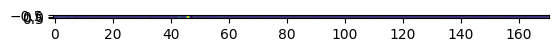

In [11]:
from matplotlib import pyplot as plt

plt.imshow(lrp_output[1][0].detach().float().cpu().numpy())

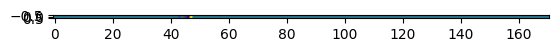

In [12]:
plt.imshow(lrp_output[1][1].detach().float().cpu().numpy())

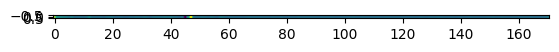

In [13]:
plt.imshow(lrp_output[1][2].detach().float().cpu().numpy())

In [14]:
torch.stack(lrp_output[1]).sum(dim=0).topk(5)

torch.return_types.topk(
values=tensor([[0.0055, 0.0048, 0.0034, 0.0033, 0.0031]], device='cuda:0',
       dtype=torch.bfloat16),
indices=tensor([[ 53,  49, 132,  54,  51]], device='cuda:0'))

In [20]:
tokenizer.decode(input_ids[0][torch.stack(lrp_output[1]).sum(dim=0).topk(5).indices.cpu()[0]])

'prize recipient [SEP]. the'

In [24]:
tokenizer.decode(input_ids[0][lrp_output[1][0].topk(5).indices.cpu()[0]])

'nobel prize recipient recipient?'